## 1_build-clean-eda_ames_plus_macro.ipynb

This code loads, merges, and cleans housing and macroeconomic data to build a final dataset for machine learning analysis.

### 1. Imports Library

In [1]:
# Imports
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from pathlib import Path
from datetime import datetime
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import os
import matplotlib.pyplot as plt
import shutil


### 2. Load and Combine Ames housing data

In [2]:
#  Load Ames train data 
df_train = pd.read_csv(Path("data/train.csv"))
df_train.head(2)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500


In [3]:
#  Load Ames test data 1
df_test_1 = pd.read_csv(Path("data/test.csv"))
df_test_1.head(2)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal


In [4]:
#  Load Ames test data 2
df_test_2 = pd.read_csv(Path("data/sample_submission.csv"))
df_test_2.head(2)

,Id,SalePrice
0,1461,169277.052498
1,1462,187758.393989


In [5]:
# Merge two parts of Ames test data on 'Id'
df_test = pd.merge(df_test_1, df_test_2, on="Id", how="inner")
df_test.head(2)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,169277.052498
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,187758.393989


In [6]:
# Union of train and test sets
df_all = pd.concat([df_train, df_test], axis=0, ignore_index=True)
df_all.head(2)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500.0
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.0


### 3. Load  Macroeconomic data(CrimeRate, InterestRate, UnemploymentRate, and MedianIncome)

#### 1) Load and preprocess CrimeRate dataset

In [7]:
# Load CrimeRate data
df_crime_rate = pd.read_csv(Path("data/Crime_Rate_lowa.csv"))
df_crime_rate.head(2)

,Year,Population,Index,Violent,Property,Murder
0,1990,2776755,113871,8321,105550,54
1,1991,2795000,115546,8477,107069,57


In [8]:
# Calculate CrimeRate
df_crime_rate["Index"] = df_crime_rate["Index"].replace(',', '', regex=True).astype(int)
df_crime_rate["Population"] = df_crime_rate["Population"].replace(',', '', regex=True).astype(int)
df_crime_rate["CrimeRate"] = df_crime_rate["Index"] / df_crime_rate["Population"] * 1000
df_crime_rate.head(2)

,Year,Population,Index,Violent,Property,Murder,CrimeRate
0,1990,2776755,113871,8321,105550,54,41.008659
1,1991,2795000,115546,8477,107069,57,41.340250


#### 2) Load and preprocess InterestRate

In [9]:
# Load InterestRate data
df_interest_rate = pd.read_csv(Path("data/Mortgage Rates USA.csv"))
df_interest_rate.head(2)

,observation_date,MORTGAGE30US
0,1/5/1990,9.83
1,1/12/1990,9.80


In [10]:
# Convert observation_date to datetime
df_interest_rate["observation_date"] = pd.to_datetime(df_interest_rate["observation_date"])

# Extract Year and Month
df_interest_rate["YearMonth"] = df_interest_rate["observation_date"].dt.to_period("M")

# Aggregate by month (median)
df_interest_rate = (
    df_interest_rate
    .groupby("YearMonth")["MORTGAGE30US"]
    .agg("median")
    .reset_index()
    .rename(columns={"MORTGAGE30US": "InterestRate"})
)

df_interest_rate.head(2)

,YearMonth,InterestRate
0,1990-01,9.865
1,1990-02,10.190


#### 3) Load and preprocess UnemploymentRate

In [11]:
# Load UnemploymentRate data
df_unemployment_rate = pd.read_csv(Path("data/AMES Unemployment Rate.csv"))
df_unemployment_rate.head(2)

,observation_date,AMES119URN
0,1990-01-01,4.2
1,1990-02-01,3.8


In [12]:
# Convert observation_date to datetime
df_unemployment_rate["observation_date"] = pd.to_datetime(df_unemployment_rate["observation_date"])

# Extract Year and Month
df_unemployment_rate["YearMonth"] = df_unemployment_rate["observation_date"].dt.to_period("M")

# Keep only YearMonth and unemployment rate, rename the column
df_unemployment_rate = (
    df_unemployment_rate[["YearMonth", "AMES119URN"]]
    .rename(columns={"AMES119URN": "UnemploymentRate"})
)

df_unemployment_rate.head(2)

,YearMonth,UnemploymentRate
0,1990-01,4.2
1,1990-02,3.8


#### 4) Load and preprocess MedianIncome

In [13]:
# Load MedianIncome data
df_median_income = pd.read_csv(Path("data/Ames Median Household Income.csv"))
df_median_income.head(2)

,Year,MedianIncome
0,1984,"19,860"
1,1985,"20,930"


### 4. Merge additional dataset into Ames housing data (MedianIncome, CrimeRate, InterestRate, and UnemploymentRate)

In [14]:
# Merge MedianIncome from df_median_income into df_all using YrSold = Year
df_all = df_all.merge(
    df_median_income[["Year", "MedianIncome"]],
    left_on="YrSold",
    right_on="Year",
    how="left"
)

# Convert MedianIncome to numeric after merging
df_all["MedianIncome"] = (
    df_all["MedianIncome"]
    .astype(str)                       # ensure string
    .str.replace(",", "", regex=False) # remove commas
    .astype(float)                     # convert to float
)

# Drop duplicate 'Year' column
df_all.drop(columns=["Year"], inplace=True)

# Check result
df_all.head(2)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,MedianIncome
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,2,2008,WD,Normal,208500.0,50140.0
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.0,48910.0


In [15]:
# Merge CrimeRate from df_crime_rate into df_all using YrSold = Year
df_all = df_all.merge(
    df_crime_rate[["Year", "CrimeRate"]],
    left_on="YrSold",
    right_on="Year",
    how="left"
)

# Drop duplicate 'Year' column
df_all.drop(columns=["Year"], inplace=True)

# Check result
df_all.head(2)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,MedianIncome,CrimeRate
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,0,2,2008,WD,Normal,208500.0,50140.0,27.363846
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,0,5,2007,WD,Normal,181500.0,48910.0,29.102296


In [16]:
# # Merge InterestRate into Ames data
# Build YearMonth in df_all as string
df_all["YearMonth"] = (
    df_all["YrSold"].astype(int).astype(str) + "-" +
    df_all["MoSold"].astype(int).astype(str).str.zfill(2)
)

# Coerce interest table YearMonth to string
df_interest_rate["YearMonth"] = df_interest_rate["YearMonth"].astype(str)

# Ensure one row per YearMonth
df_interest_rate = (
    df_interest_rate
    .sort_values("YearMonth")
    .drop_duplicates(subset=["YearMonth"], keep="last")
)

# Merge
df_all = df_all.merge(df_interest_rate, on="YearMonth", how="left")

df_all.head(2)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,MedianIncome,CrimeRate,YearMonth,InterestRate
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,2,2008,WD,Normal,208500.0,50140.0,27.363846,2008-02,5.88
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,5,2007,WD,Normal,181500.0,48910.0,29.102296,2007-05,6.21


In [17]:
# Merge UnemploymentRate into Ames data
# Convert UnemploymentRate table YearMonth to string
df_unemployment_rate["YearMonth"] = df_unemployment_rate["YearMonth"].astype(str)

# Ensure one row per YearMonth
df_unemployment_rate = (
    df_unemployment_rate
    .sort_values("YearMonth")
    .drop_duplicates(subset=["YearMonth"], keep="last")
)

# Merge
df_all = df_all.merge(df_unemployment_rate, on="YearMonth", how="left")

# Drop 'YearMonth' column
df_all.drop(columns=["YearMonth"], inplace=True)

df_all.head(2)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,MedianIncome,CrimeRate,InterestRate,UnemploymentRate
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,2,2008,WD,Normal,208500.0,50140.0,27.363846,5.88,3.1
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,5,2007,WD,Normal,181500.0,48910.0,29.102296,6.21,2.8


In [18]:
# Check data 
# 1. View the shape
print("Dataset shape (rows, columns):")
print(df_all.shape)

# 2. View information
print("\nDataset information:")
df_all.info()

Dataset shape (rows, columns):
(2919, 85)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 85 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Id                2919 non-null   int64  
 1   MSSubClass        2919 non-null   int64  
 2   MSZoning          2915 non-null   object 
 3   LotFrontage       2433 non-null   float64
 4   LotArea           2919 non-null   int64  
 5   Street            2919 non-null   object 
 6   Alley             198 non-null    object 
 7   LotShape          2919 non-null   object 
 8   LandContour       2919 non-null   object 
 9   Utilities         2917 non-null   object 
 10  LotConfig         2919 non-null   object 
 11  LandSlope         2919 non-null   object 
 12  Neighborhood      2919 non-null   object 
 13  Condition1        2919 non-null   object 
 14  Condition2        2919 non-null   object 
 15  BldgType          2919 no

### 5 Basic Data Cleaning

#### 1) Drop Id column

In [19]:
# Copy original dataset
df_clean = df_all.copy()

# Drop Id column
df_clean = df_clean.drop(["Id"],axis=1)
df_clean.head(2)


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,MedianIncome,CrimeRate,InterestRate,UnemploymentRate
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,2,2008,WD,Normal,208500.0,50140.0,27.363846,5.88,3.1
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,5,2007,WD,Normal,181500.0,48910.0,29.102296,6.21,2.8


#### 2) Handle Duplicates

In [20]:
# Check and drop duplicates
n_dupes = df_clean.duplicated().sum()
print(f"[Duplicates] Found: {n_dupes}")
if n_dupes > 0:
    df_clean = df_clean.drop_duplicates().reset_index(drop=True)
    print(f"[Duplicates] Dropped. New shape: {df_clean.shape}")

[Duplicates] Found: 0


#### 3) Handle Missing values

Rule:
- For numeric columns, treat the string "NA" as missing (convert to NaN).
- For categorical columns, keep "NA" as a legitimate category.

In [21]:
# Handle Missing values
# 1) Identify numeric vs categorical
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_clean.select_dtypes(exclude=[np.number]).columns.tolist()

# 2) In categorical cols: replace literal "NA" with string "Without"
for c in cat_cols:
    df_clean[c] = df_clean[c].replace(
        to_replace=[r"^\s*NA\s*$", r"^\s*na\s*$", r"^\s*Na\s*$", r"^\s*n/a\s*$"],
        value="Without", regex=True
    )
    df_clean[c] = df_clean[c].fillna("Without")  

# 3) Show missing summary BEFORE imputing
print("\n[Median Imputation BEFORE] Number of missing values per column:")
print(df_clean.isna().sum()[df_clean.isna().sum() > 0].sort_values(ascending=False))

# 4) Impute numeric via median imputation
for c in num_cols:
    if df_clean[c].isna().any():
        median_val = df_clean[c].median()
        df_clean[c] = df_clean[c].fillna(median_val)

# 5) Show missing summary AFTER imputing
print("\n[Median Imputation AFTER] Total missing cells across dataset:",
      df_clean.isna().sum().sum())



[Median Imputation BEFORE] Number of missing values per column:
LotFrontage     486
GarageYrBlt     159
MasVnrArea       23
BsmtFullBath      2
BsmtHalfBath      2
BsmtFinSF1        1
BsmtFinSF2        1
BsmtUnfSF         1
TotalBsmtSF       1
GarageCars        1
GarageArea        1
dtype: int64

[Median Imputation AFTER] Total missing cells across dataset: 0


In [22]:
#Display
df_clean[cat_cols].head(2)

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
0,RL,Pave,Without,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Attchd,RFn,TA,TA,Y,Without,Without,Without,WD,Normal
1,RL,Pave,Without,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,...,Attchd,RFn,TA,TA,Y,Without,Without,Without,WD,Normal


### 6 Exploratory Data Analysis(EDA)

#### Basic Explore

In [23]:
# 1. View the shape
print("Dataset shape (rows, columns):")
print(df_all.shape)

# 2. View comprehensive information
print("\nDataset information:")
df_all.info()
print()

# 3. View descriptive statistics
print("Dataset descriptive statistics:")
print(df_all.describe(include='all'))

Dataset shape (rows, columns):
(2919, 85)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 85 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Id                2919 non-null   int64  
 1   MSSubClass        2919 non-null   int64  
 2   MSZoning          2915 non-null   object 
 3   LotFrontage       2433 non-null   float64
 4   LotArea           2919 non-null   int64  
 5   Street            2919 non-null   object 
 6   Alley             198 non-null    object 
 7   LotShape          2919 non-null   object 
 8   LandContour       2919 non-null   object 
 9   Utilities         2917 non-null   object 
 10  LotConfig         2919 non-null   object 
 11  LandSlope         2919 non-null   object 
 12  Neighborhood      2919 non-null   object 
 13  Condition1        2919 non-null   object 
 14  Condition2        2919 non-null   object 
 15  BldgType          2919 no

#### Visualizations

##### 1) Correlation heatmap → see relationships

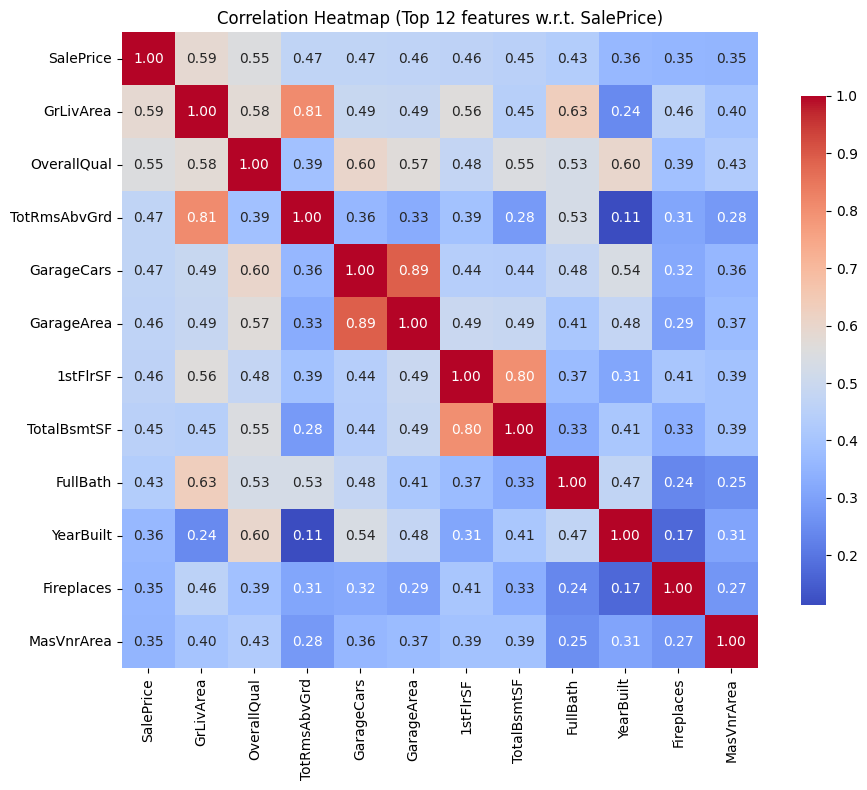

In [24]:
# CORRELATION HEATMAP
if "SalePrice" in df_clean.columns and df_clean["SalePrice"].dtype != "O":
    numeric_df = df_clean[num_cols].copy()
    corr = numeric_df.corr(numeric_only=True)

    if "SalePrice" in corr.columns:
        top_cols = (
            corr["SalePrice"].abs()
            .sort_values(ascending=False)
            .head(12)   # Top 12 correlations
            .index.tolist()
        )
        corr_subset = corr.loc[top_cols, top_cols]
    else:
        corr_subset = corr.iloc[:13, :13]

    plt.figure(figsize=(10,8))
    sns.heatmap(corr_subset, annot=True, fmt=".2f", cmap="coolwarm", square=True,
                cbar_kws={"shrink": .8})
    plt.title("Correlation Heatmap (Top 12 features w.r.t. SalePrice)")
    plt.tight_layout()
    plt.show()

##### 2)Histograms or BAR PLOTS → check distribution / skew

In [25]:
# Utility: plot in grid (n_cols = 3)
def plot_grid(plot_func, cols, n_cols=3, figsize=(20, 32)):
    n_rows = int(np.ceil(len(cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten()

    for i, col in enumerate(cols):
        try:
            plot_func(col, axes[i])
        except Exception as e:
            print(f"Skipping {col}: {e}")
            continue

    # Hide empty subplots
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()
    
def hist_func(col, ax):
    data = df_clean[col].dropna()
    ax.hist(data, bins=30, edgecolor='black')
    ax.set_title(col, fontsize=9)

SalePrice distribution plot saved to: output\saleprice_distribution.png


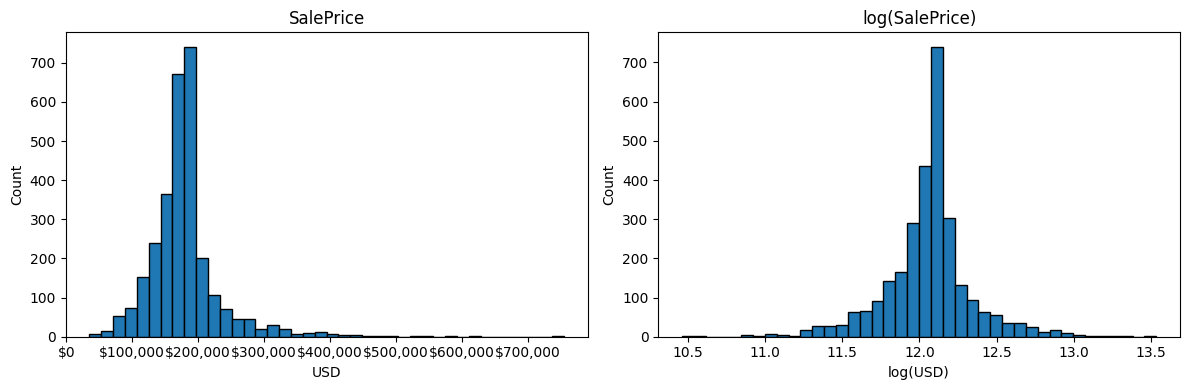

In [26]:
# 1) Make sure SalePrice is numeric and create log(SalePrice)
df_clean["SalePrice"] = pd.to_numeric(df_clean["SalePrice"], errors="coerce")
df_clean["log_SalePrice"] = np.log(df_clean["SalePrice"])  # SalePrice > 0 in Ames

# 2) Plot side-by-side histograms
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# SalePrice (original scale)
axes[0].hist(df_clean["SalePrice"].dropna(), bins=40, edgecolor="black")
axes[0].set_title("SalePrice")
axes[0].set_xlabel("USD")
axes[0].set_ylabel("Count")
axes[0].xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"${x:,.0f}"))

# log(SalePrice)
axes[1].hist(df_clean["log_SalePrice"].dropna(), bins=40, edgecolor="black")
axes[1].set_title("log(SalePrice)")
axes[1].set_xlabel("log(USD)")
axes[1].set_ylabel("Count")

plt.tight_layout()

# Save the graph as PNG file
saleprice_plot_path = Path("output") / "saleprice_distribution.png"
plt.savefig(saleprice_plot_path, dpi=300, bbox_inches='tight')
print(f"SalePrice distribution plot saved to: {saleprice_plot_path}")

# Display the graph
plt.show()

[LotFrontage histogram saved to: output\lotfrontage_histogram.png


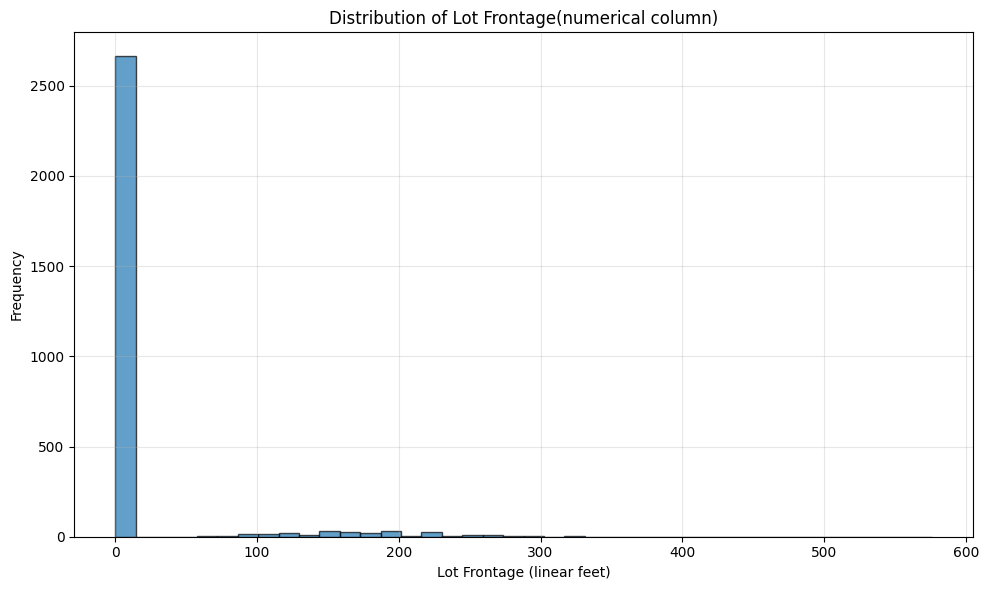

In [27]:
# HISTOGRAM for LotFrontage (numerical column sample)
# Create histogram for LotFrontage
plt.figure(figsize=(10, 6))
plt.hist(df_clean["ScreenPorch"].dropna(), bins=40, edgecolor="black", alpha=0.7)
plt.title("Distribution of Lot Frontage(numerical column)")
plt.xlabel("Lot Frontage (linear feet)")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)

plt.tight_layout()

# Save the histogram as PNG file
lotfrontage_plot_path = Path("output") / "lotfrontage_histogram.png"
plt.savefig(lotfrontage_plot_path, dpi=300, bbox_inches='tight')
print(f"[LotFrontage histogram saved to: {lotfrontage_plot_path}")

# Display the graph
plt.show()

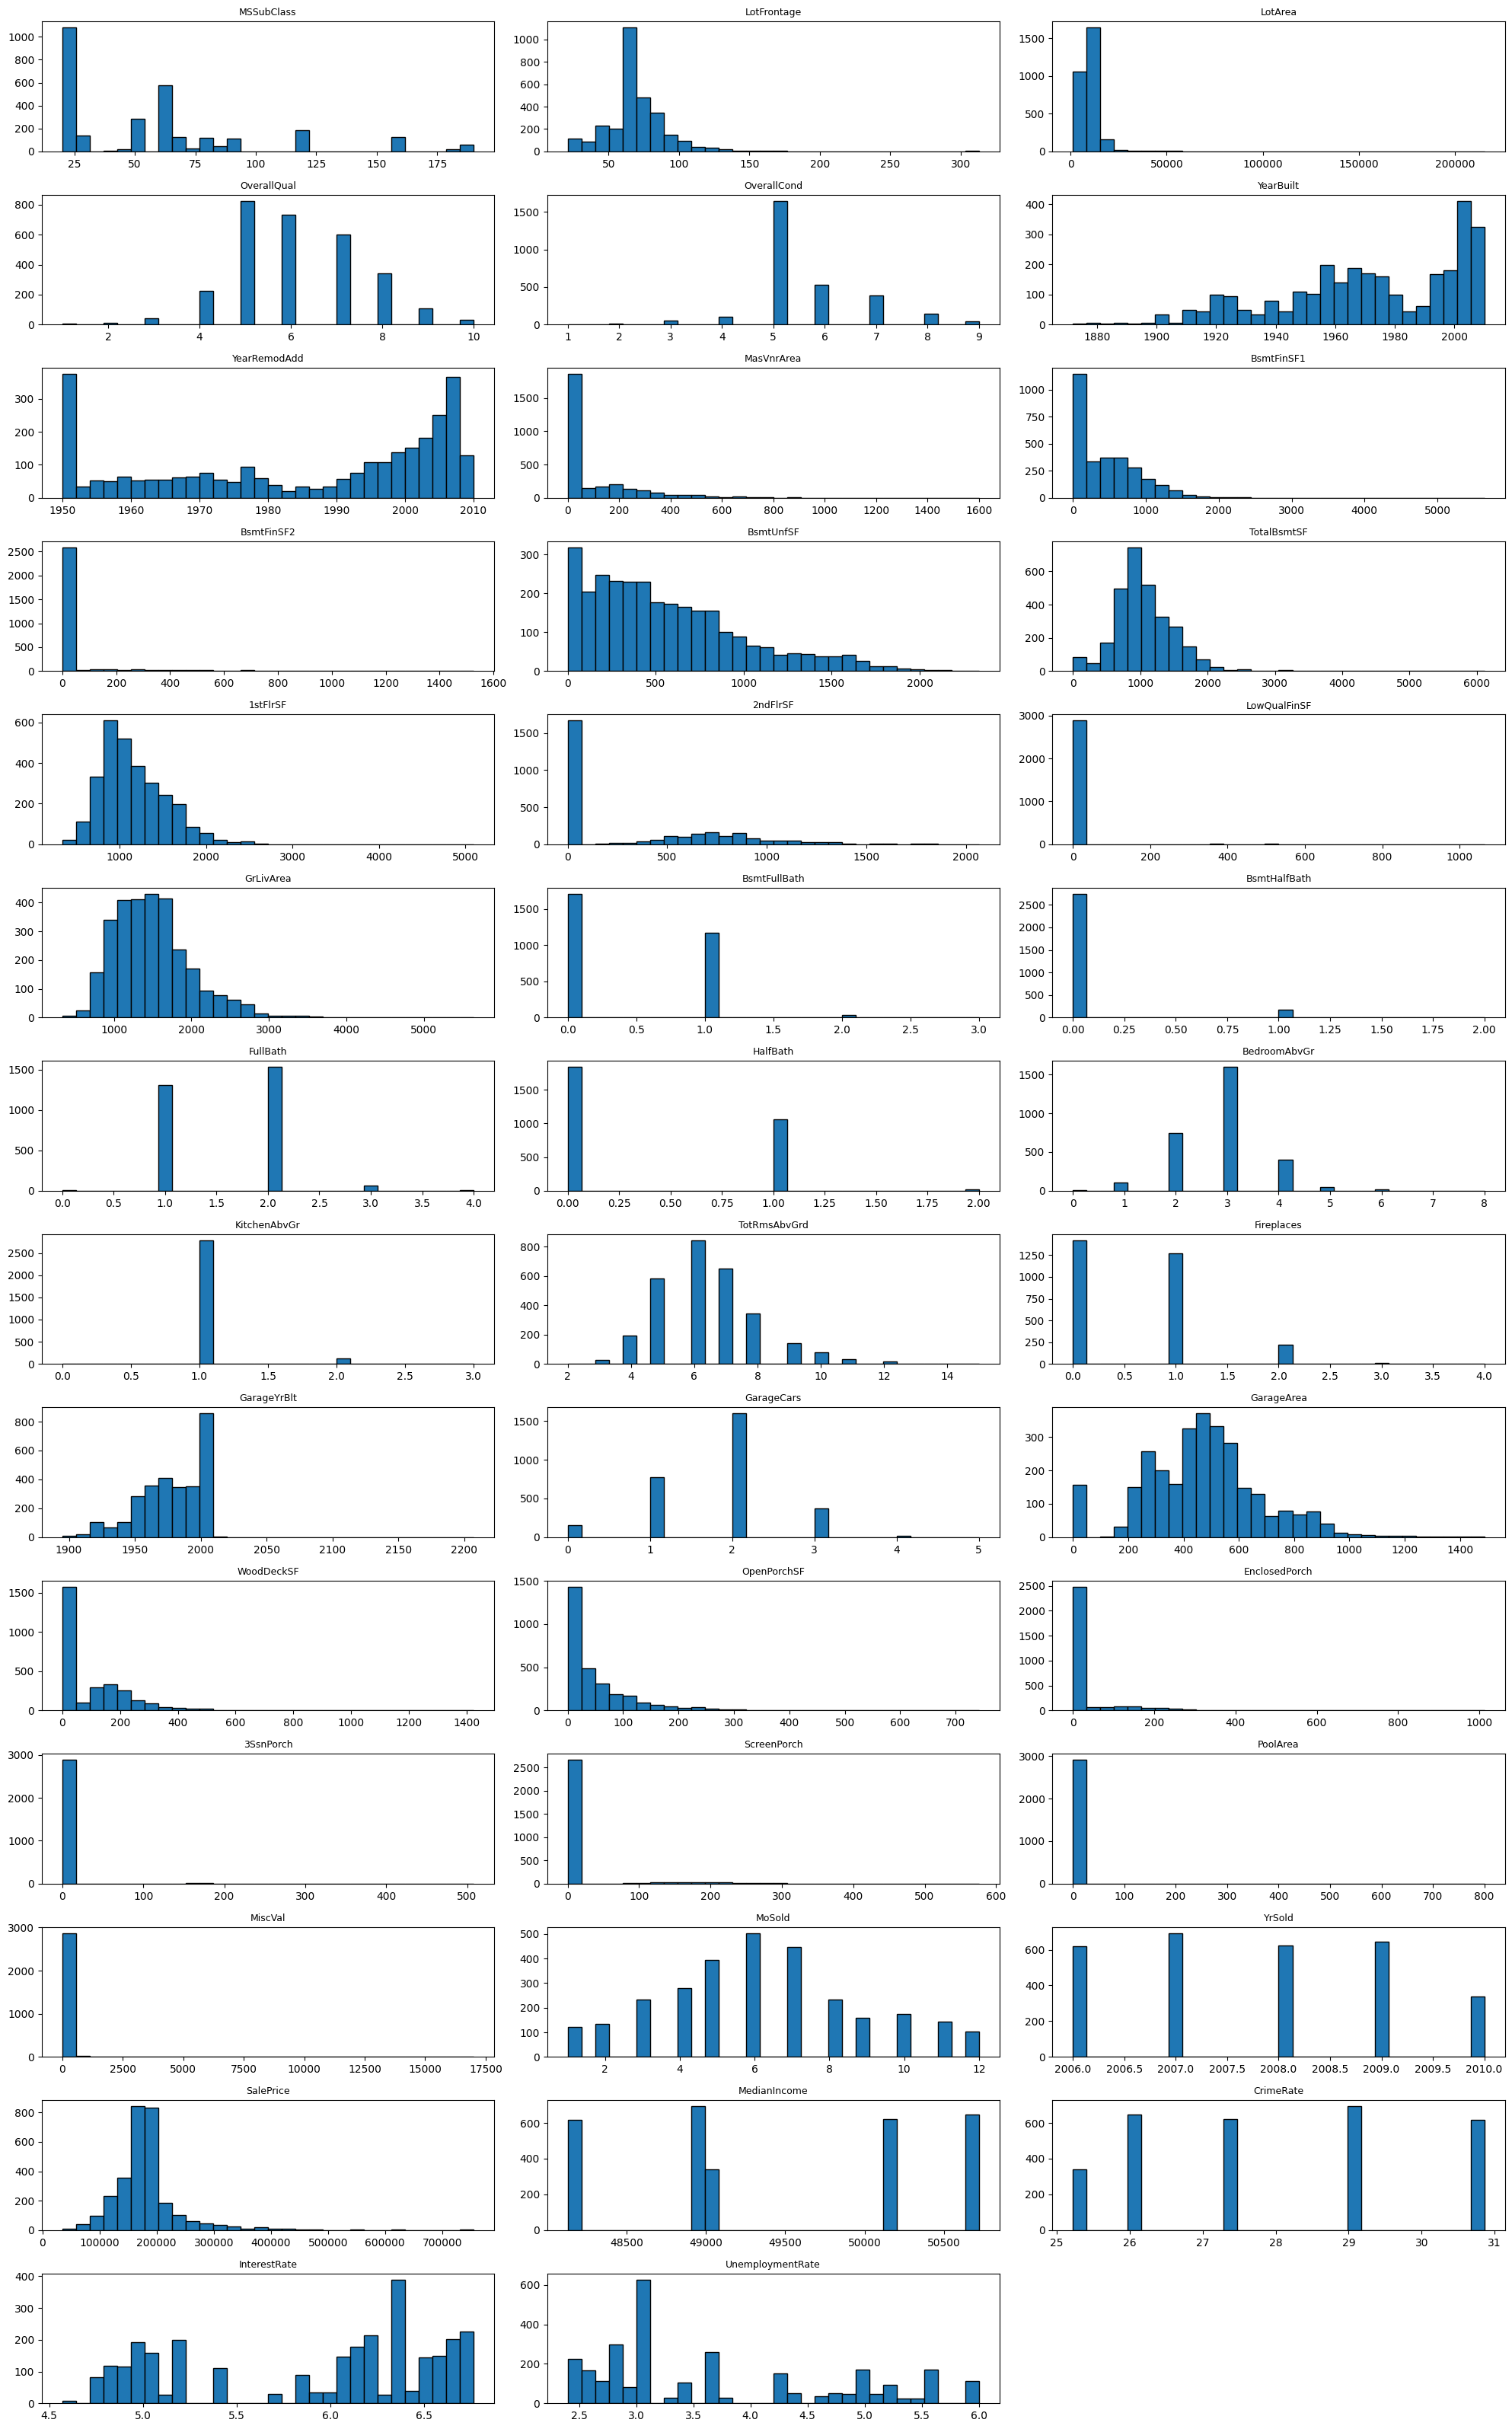

In [28]:
# HISTOGRAMS for numerical columns
plot_grid(hist_func, num_cols)

Crime rate trends plot saved to: output\crime_rate_trends.png


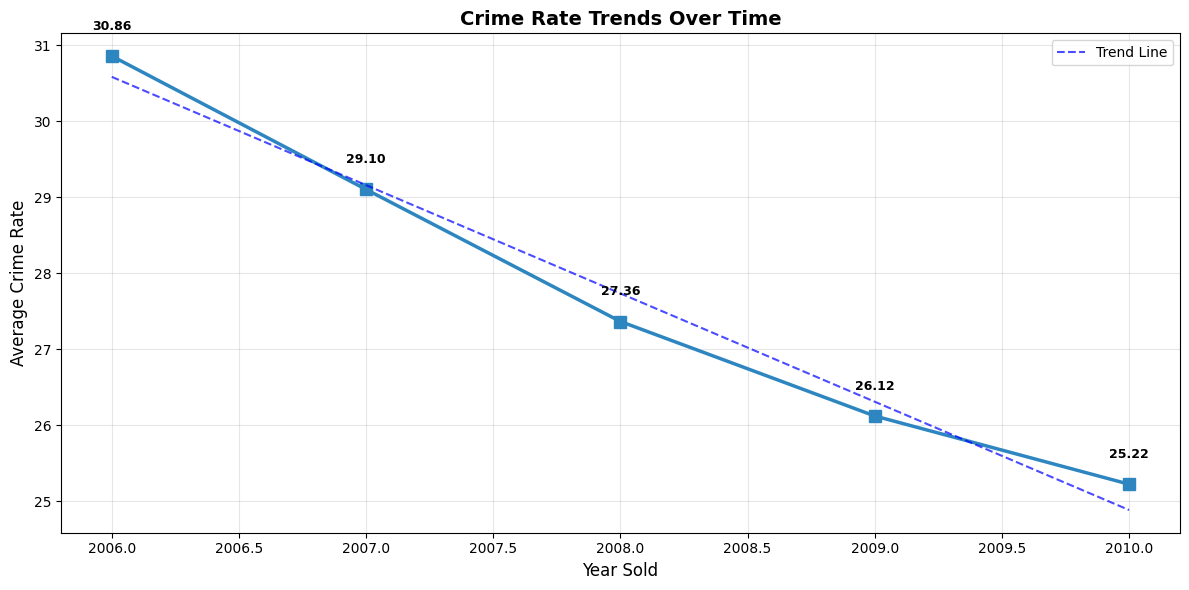

In [29]:
# LINE PLOT FOR CRIME RATE OVER TIME
plt.figure(figsize=(12, 6))

# Group by year and calculate average crime rate
crime_by_year = df_clean.groupby('YrSold')['CrimeRate'].mean().sort_index()

# Create line plot
plt.plot(crime_by_year.index, crime_by_year.values, 
         marker='s', linewidth=2.5, markersize=8, color='#2E86C1', markerfacecolor='#2E86C1')

# Customize the plot
plt.title('Crime Rate Trends Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Year Sold', fontsize=12)
plt.ylabel('Average Crime Rate', fontsize=12)
plt.grid(True, alpha=0.3)

# Add value annotations on data points
for year, rate in crime_by_year.items():
    plt.text(year, rate + (crime_by_year.max() * 0.01), f'{rate:.2f}', 
             ha='center', va='bottom', fontsize=9, fontweight='bold')

# Add trend line
z = np.polyfit(crime_by_year.index, crime_by_year.values, 1)
p = np.poly1d(z)
plt.plot(crime_by_year.index, p(crime_by_year.index), 
         "b--", alpha=0.7, linewidth=1.5, label='Trend Line')

plt.legend()
plt.tight_layout()

# Save the line plot as PNG file
crime_plot_path = Path("output") / "crime_rate_trends.png"
plt.savefig(crime_plot_path, dpi=300, bbox_inches='tight')
print(f"Crime rate trends plot saved to: {crime_plot_path}")

# Display the graph
plt.show()

Neighborhood bar plot saved to: output\neighborhood_distribution.png


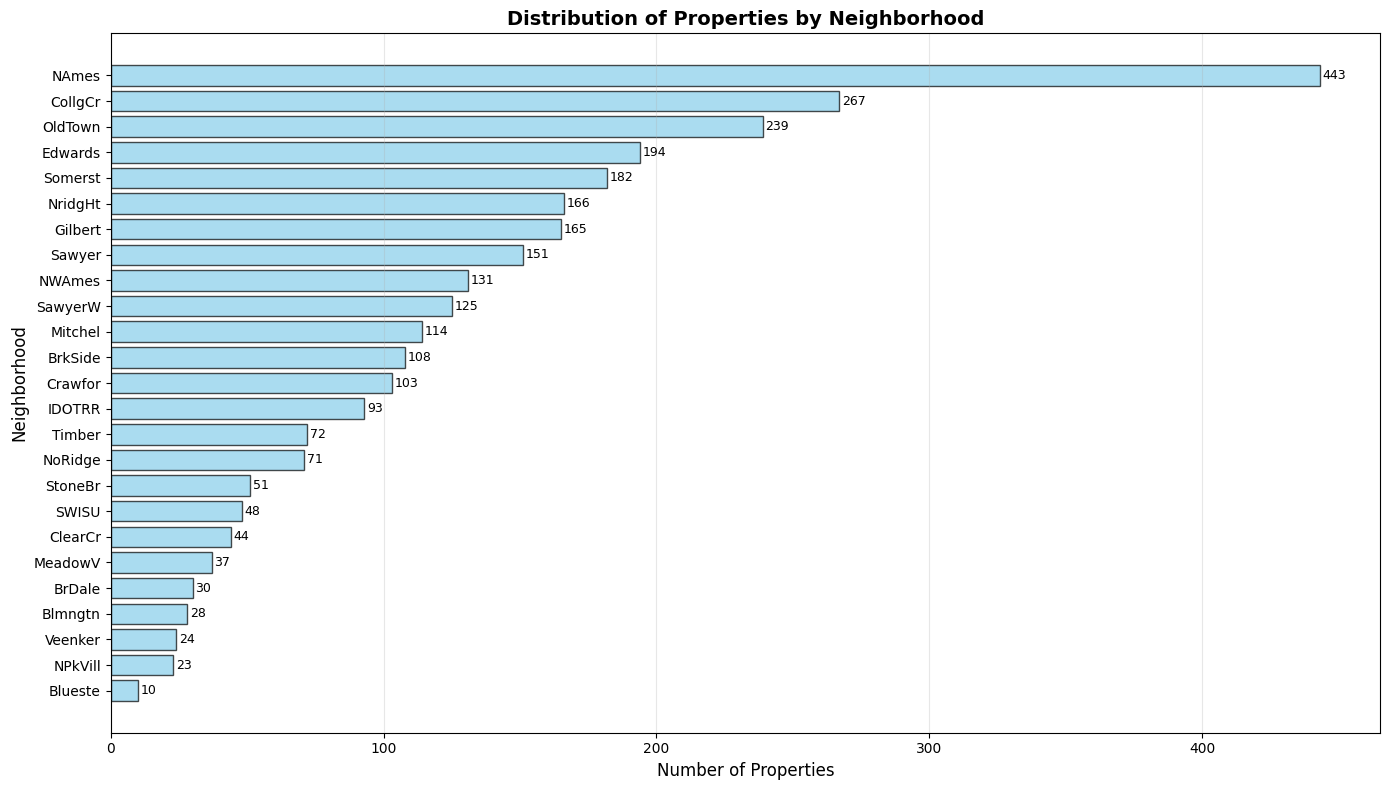

In [30]:
# Bar plots for Neighborhood (categorical column)
plt.figure(figsize=(14, 8))

# Count the frequency of each neighborhood and sort by count
neighborhood_counts = df_clean["Neighborhood"].value_counts().sort_values(ascending=True)

# Create horizontal bar plot
bars = plt.barh(range(len(neighborhood_counts)), neighborhood_counts.values, color='skyblue', edgecolor='black', alpha=0.7)

# Customize the plot
plt.yticks(range(len(neighborhood_counts)), neighborhood_counts.index)
plt.title("Distribution of Properties by Neighborhood", fontsize=14, fontweight='bold')
plt.xlabel("Number of Properties", fontsize=12)
plt.ylabel("Neighborhood", fontsize=12)
plt.grid(True, axis='x', alpha=0.3)

# Add value labels on the bars
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2, f'{int(width)}', 
             ha='left', va='center', fontsize=9)

plt.tight_layout()

# Save the bar plot as PNG file
neighborhood_plot_path = Path("output") / "neighborhood_distribution.png"
plt.savefig(neighborhood_plot_path, dpi=300, bbox_inches='tight')
print(f"Neighborhood bar plot saved to: {neighborhood_plot_path}")

# Display the graph
plt.show()

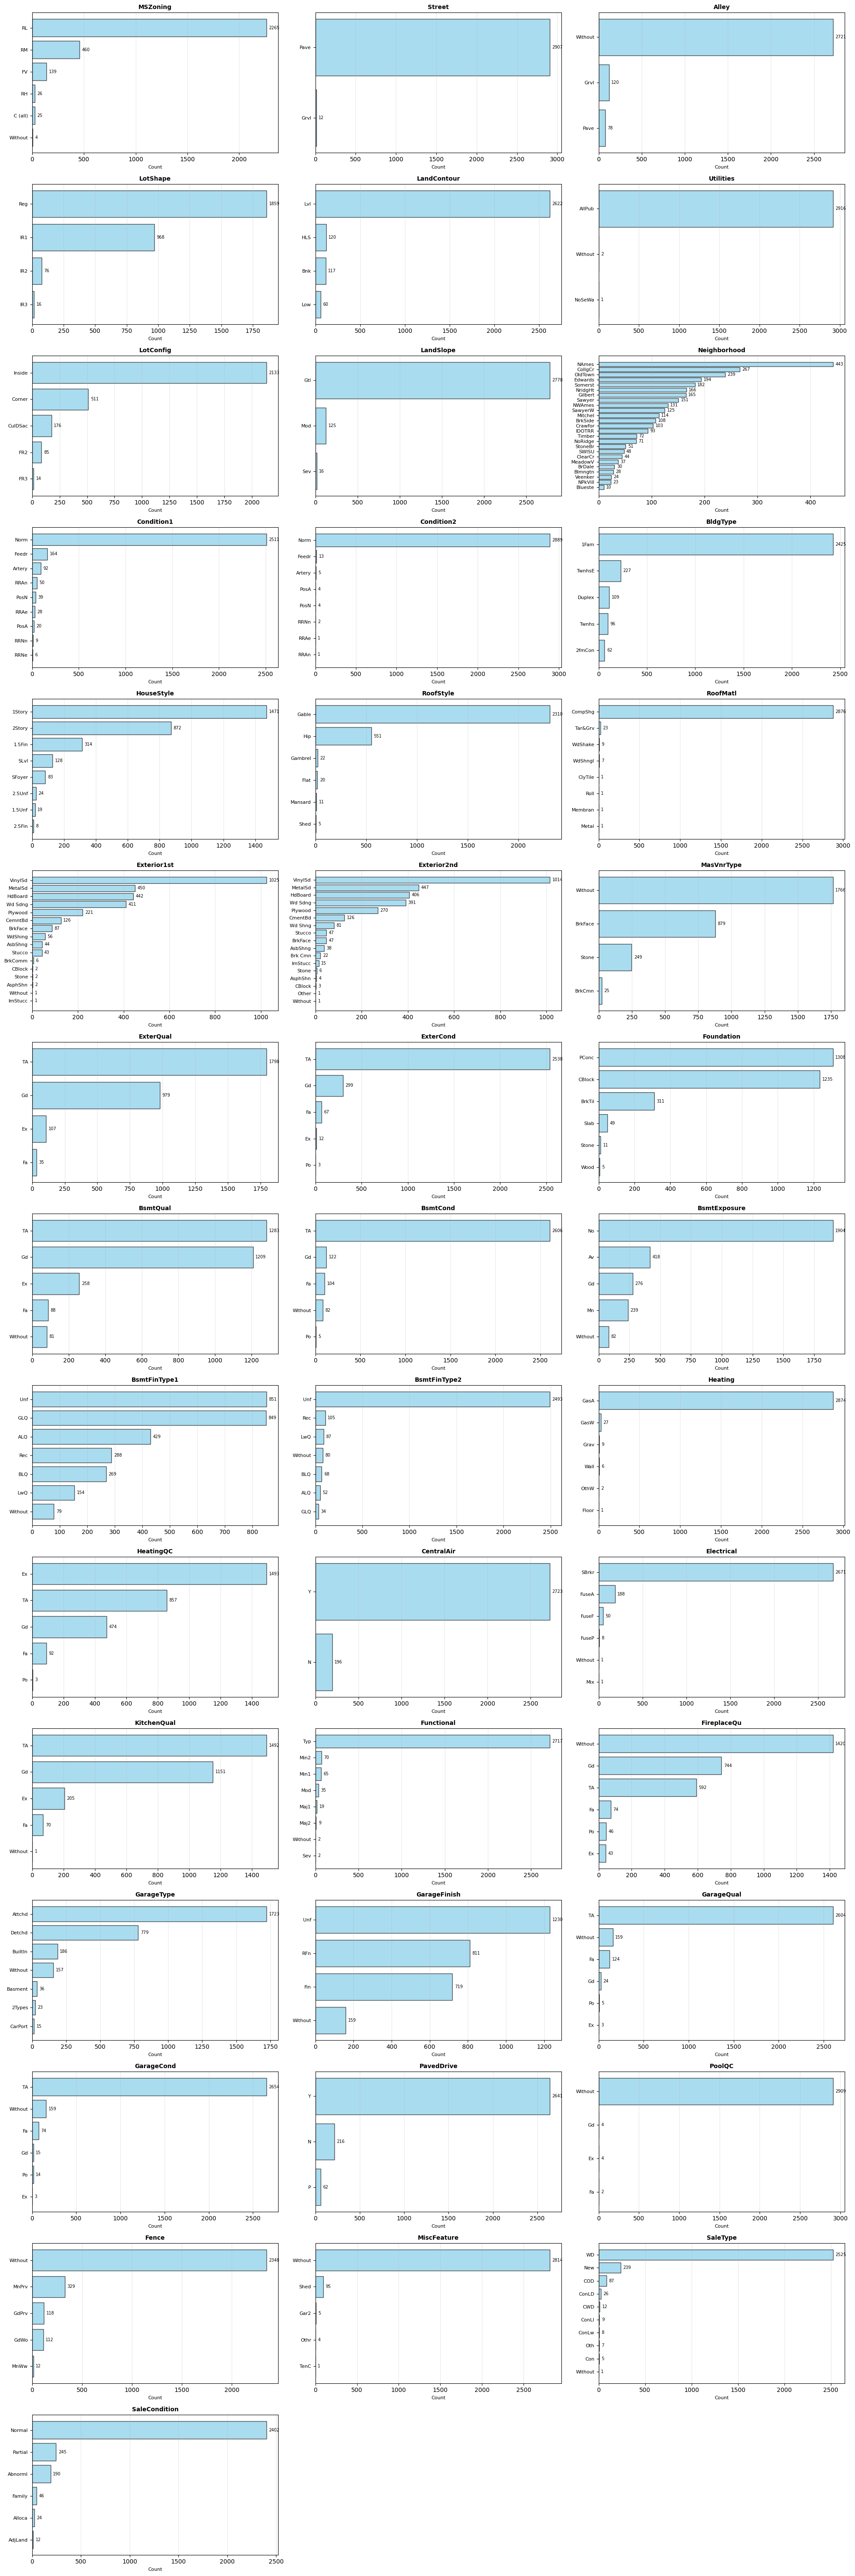

In [31]:
# CATEGORICAL: BAR PLOTS
def bar_func(col, ax):
    # Get value counts and handle missing values
    vc = df_clean[col].astype("string").fillna("Missing").value_counts()
    
    # Sort by frequency for better visualization
    vc_sorted = vc.sort_values(ascending=True)
    
    # Create horizontal bar plot
    bars = ax.barh(range(len(vc_sorted)), vc_sorted.values, color='skyblue', edgecolor='black', alpha=0.7)
    
    # Customize the plot
    ax.set_yticks(range(len(vc_sorted)))
    ax.set_yticklabels(vc_sorted.index, fontsize=8)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('Count', fontsize=8)
    ax.grid(True, axis='x', alpha=0.3)
    
    # Add value labels on the bars if there's enough space
    max_count = vc_sorted.max()
    if max_count > 10:  # Only add labels if bars are reasonably sized
        for i, bar in enumerate(bars):
            width = bar.get_width()
            ax.text(width + max_count * 0.01, bar.get_y() + bar.get_height()/2, 
                   f'{int(width)}', ha='left', va='center', fontsize=7)

# Create the grid plot
plot_grid(bar_func, cat_cols, figsize=(20, 60))

##### 3)Lineplots – Macro Factors over Time

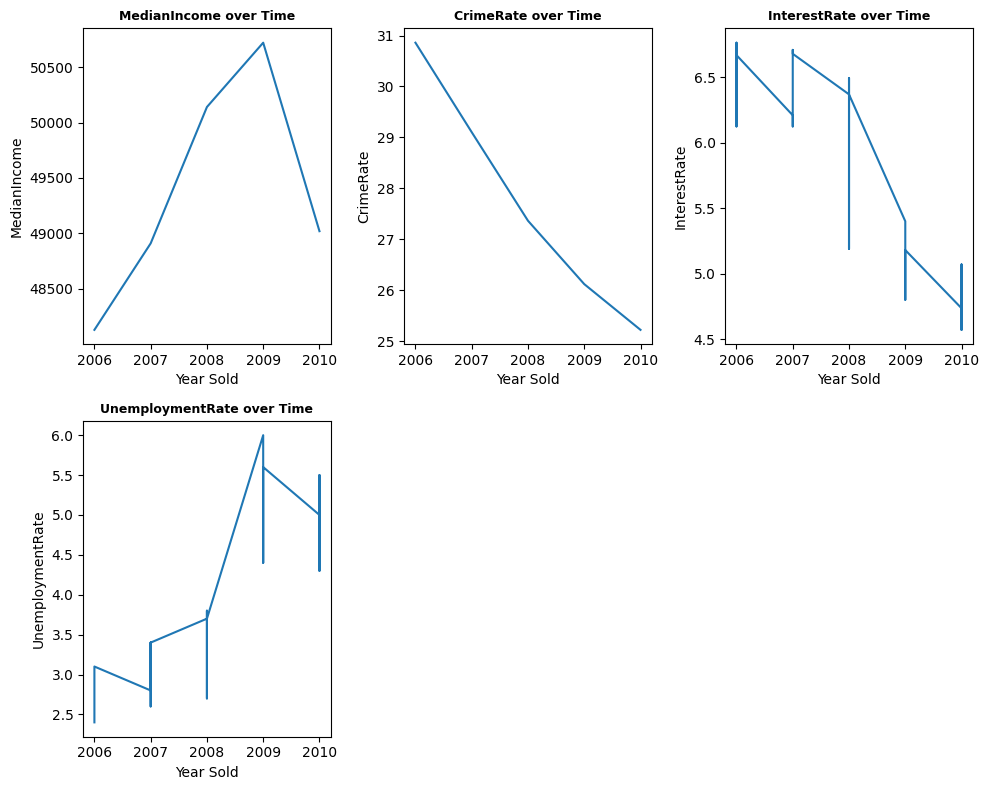

In [32]:
# Line plot function 
def line_func(col, ax):
    # Remove missing values 
    data = df_clean[['YrSold', col]].dropna()
    
    # Sort by year so the line follows time order
    data = data.sort_values('YrSold')
    
    # Simple line plot: macro factor vs year
    ax.plot(data['YrSold'], data[col])
    
    # Set title and axis labels
    ax.set_title(f"{col} over Time", fontsize=9, fontweight='bold')
    ax.set_xlabel("Year Sold")
    ax.set_ylabel(col)


# Define macroeconomic columns
macro_cols = ['MedianIncome','CrimeRate','InterestRate','UnemploymentRate']

# Plot all macro variables
plot_grid(line_func, macro_cols, figsize=(10, 8))

##### 4)Boxplots → check outliers.

Overallqual boxplot saved to: output\overallqual_boxplot.png


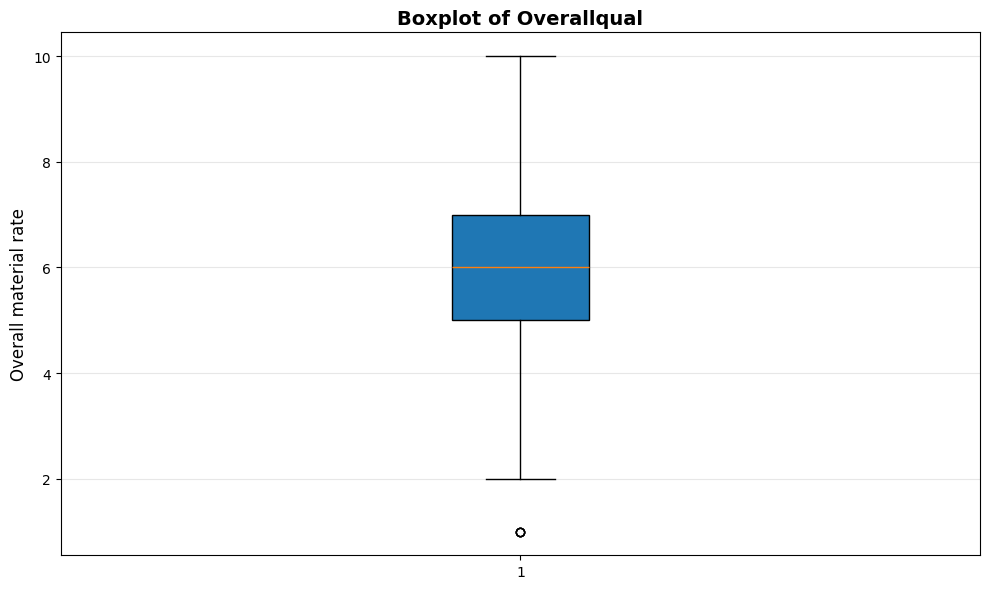

In [33]:
# BOXPLOT FOR OVERALLQUAL ONLY
plt.figure(figsize=(10, 6))

# Create boxplot for Overallqual
data = df_clean["OverallQual"].dropna()
plt.boxplot(data, vert=True, whis=1.5, patch_artist=True)

# Customize the plot
plt.title("Boxplot of Overallqual", fontsize=14, fontweight='bold')
plt.ylabel("Overall material rate", fontsize=12)
plt.grid(True, axis='y', alpha=0.3)

plt.tight_layout()

# Save the boxplot as PNG file
overallqual_boxplot_path = Path("output") / "overallqual_boxplot.png"
plt.savefig(overallqual_boxplot_path, dpi=300, bbox_inches='tight')
print(f"Overallqual boxplot saved to: {overallqual_boxplot_path}")

# Display the graph
plt.show()

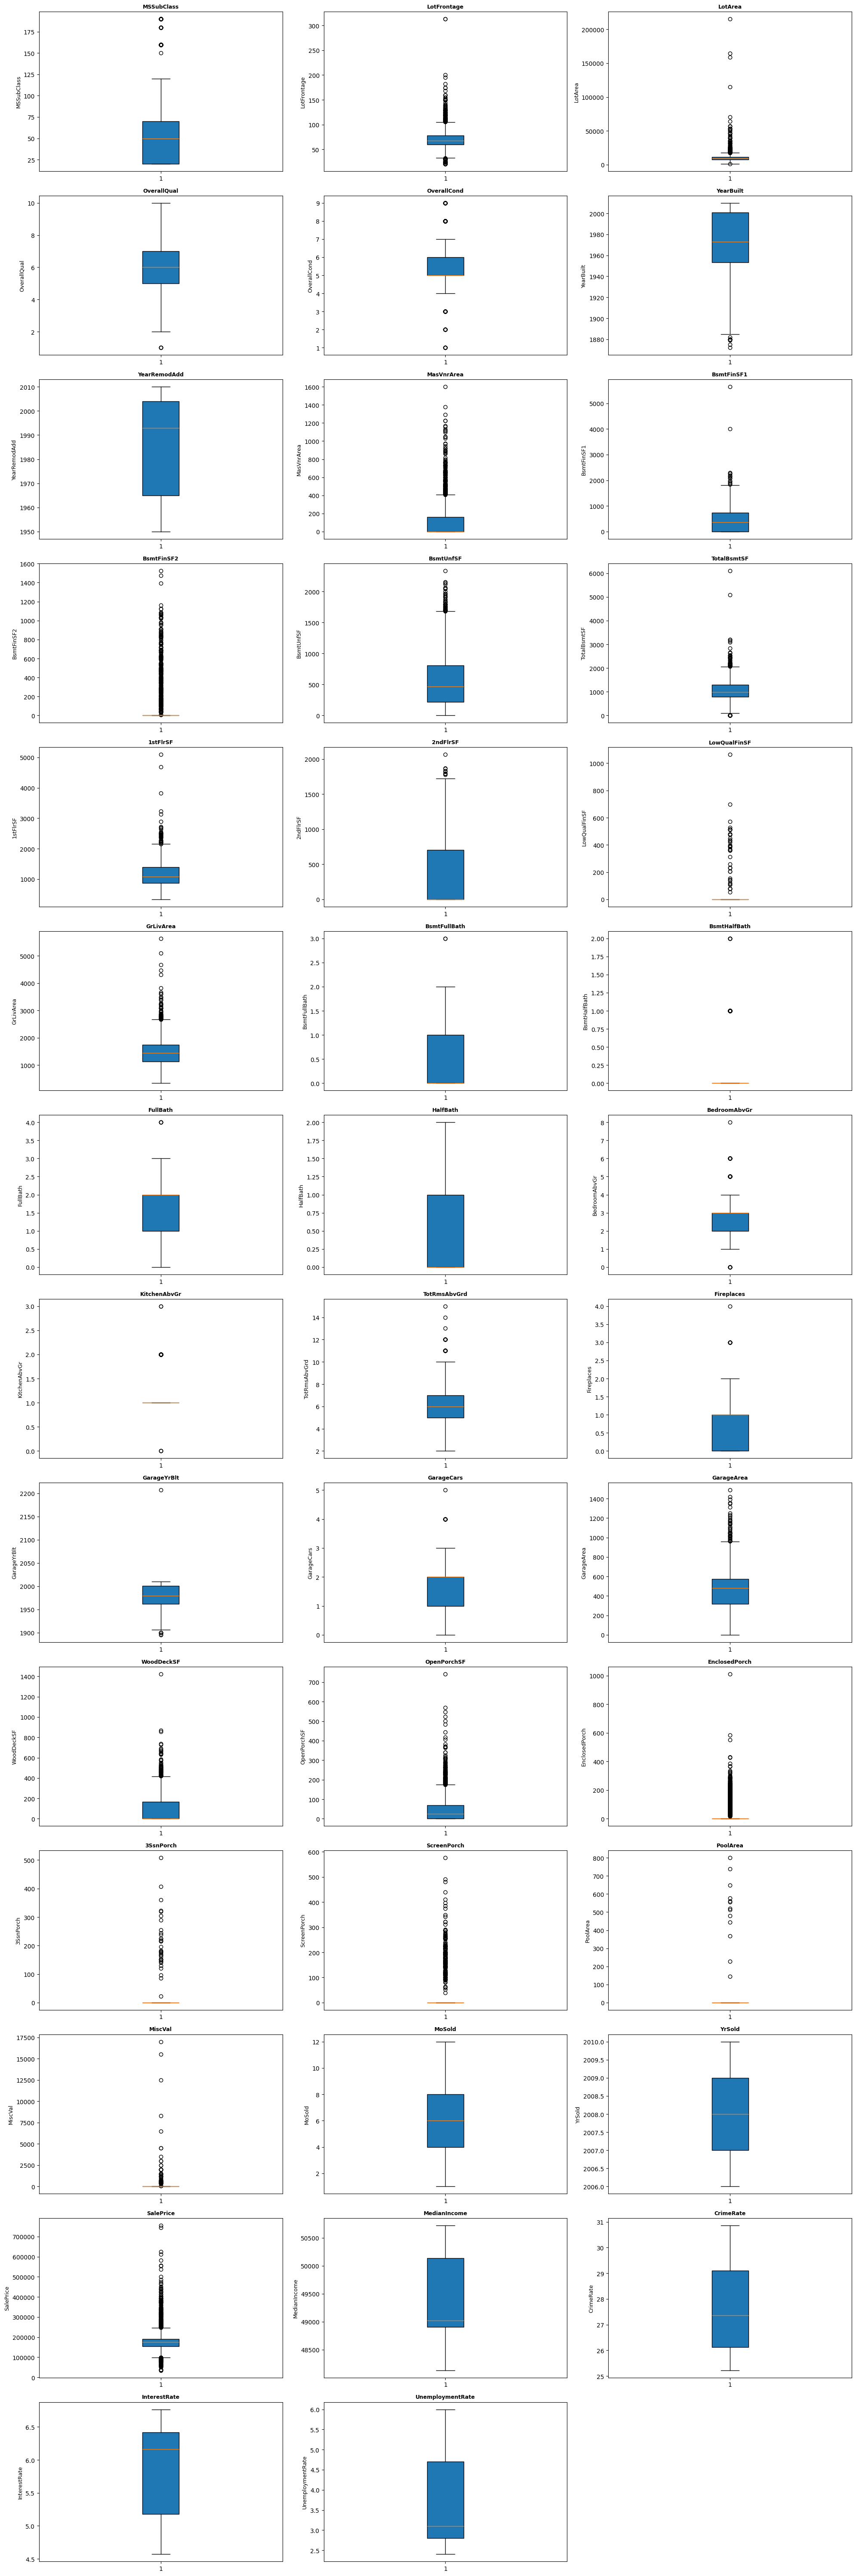

In [34]:
# NUMERICAL: BOXPLOTS
def box_func(col, ax):
    data = df_clean[col].dropna()
    ax.boxplot(data, vert=True, whis=1.5, patch_artist=True)
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.set_ylabel(col, fontsize=9)

plot_grid(box_func, num_cols, figsize=(20, 60))


### 7. Save 

In [35]:
# Save the cleaned dataset
# Define folder name
folder_name = "output/preprocess_csv"

# Save df_clean to the new folder
output_path = os.path.join(folder_name, "df_clean.csv")
df_clean.to_csv(output_path, index=False)
print(f"Cleaned dataset saved to: {output_path}")

Cleaned dataset saved to: output/preprocess_csv\df_clean.csv
